<a href="https://colab.research.google.com/github/awfajri/artificial-intelligence/blob/main/Studi_kasus_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Studi kasus 1 - Auf Fajri Ramadhani




Kelas : 4F

NPM : 2410631170059



---



#**soal**
Andri adalah seorang karyawan yang bekerja di salah satu perusahaan di Kawasan Industri
Wijayakusuma, kota Semarang. Pada saat libur hari raya idul fitri nanti, Andri berencana untuk
mengunjungi keluarganya di Cilacap. Namun, ia tidak tahu rute perjalanan yang harus ia lalui
untuk sampai tujuan. Andri hanya memiliki peta jawa tengah yang berbentuk graph berisi nama
nama kota di jawa tengah. Namun, dia belum memiliki jarak masing masing kota tersebut.
Bantulah andri untuk menentukan rute perjalanan terbaiknya!

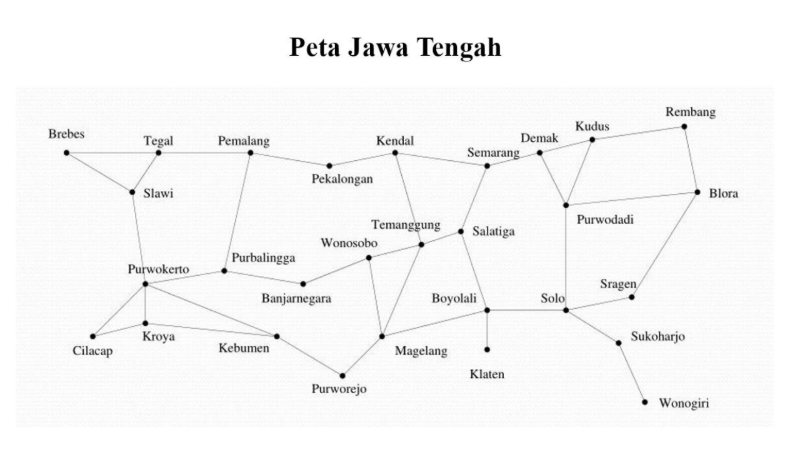

**Jawab**

1. import library

In [ ]:
import heapq
from typing import Dict, List, Tuple

Di bagian awal ini, saya mengimpor heapq yang fungsinya untuk mengelola priority queue. Library ini penting banget karena Best First Search butuh alat buat selalu nemuin kota dengan jarak heuristik paling kecil secara otomatis. Selain itu, saya pakai typing biar pendefinisian variabel di fungsi nanti lebih rapi dan gampang dibaca.


---



2. Data jarak antar kota

In [ ]:
graph = {
    'Semarang':     {'Demak': 29.0, 'Kendal': 30.8, 'Salatiga': 51.5},
    'Demak':        {'Semarang': 29.0},
    'Kendal':       {'Semarang': 30.8, 'Temanggung': 71.0, 'Pekalongan': 68.2},
    'Salatiga':     {'Semarang': 51.5, 'Temanggung': 55.6},
    'Temanggung':   {'Salatiga': 55.6, 'Magelang': 28.2, 'Wonosobo': 39.1, 'Kendal': 71.0},
    'Magelang':     {'Temanggung': 28.2, 'Wonosobo': 58.4, 'Purworejo': 44.1},
    'Wonosobo':     {'Temanggung': 39.1, 'Magelang': 58.4, 'Banjarnegara': 47.3},
    'Banjarnegara': {'Wonosobo': 47.3, 'Purbalingga': 28.2},
    'Purbalingga':  {'Banjarnegara': 28.2, 'Purwokerto': 19.9, 'Pemalang': 68.8},
    'Purwokerto':   {'Purbalingga': 19.9, 'Kebumen': 69.2, 'Cilacap': 49.5, 'Slawi': 89.0},
    'Kebumen':      {'Purworejo': 42.1, 'Kroya': 53.0, 'Purwokerto': 69.2},
    'Purworejo':    {'Magelang': 44.1, 'Kebumen': 42.1},
    'Kroya':        {'Kebumen': 53.0, 'Cilacap': 29.1},
    'Cilacap':      {'Kroya': 29.1, 'Purwokerto': 49.5},
    'Pekalongan':   {'Kendal': 68.2, 'Pemalang': 50.6},
    'Pemalang':     {'Pekalongan': 50.6, 'Purbalingga': 68.8, 'Tegal': 32.7},
    'Tegal':        {'Pemalang': 32.7, 'Slawi': 13.1, 'Brebes': 13.9},
    'Brebes':       {'Tegal': 13.9, 'Slawi': 25.4},
    'Slawi':        {'Tegal': 13.1, 'Brebes': 25.4, 'Purwokerto': 89.0}
}

Di sini saya membuat struktur graf berdasarkan hasil pencarian manual di Google Maps. Setiap kota saya hubungkan dengan tetangganya beserta jarak rute aslinya (km). Data ini saya susun dalam bentuk dictionary biar sistem bisa dengan mudah menelusuri rute mana saja yang bisa dilewati Andri dari Semarang menuju Cilacap.


---



3. data heuristic (jarak garis lurus ke cilacap)

In [ ]:
heuristic = {
    'Semarang': 174, 'Kendal': 156, 'Demak': 199, 'Salatiga': 169,
    'Temanggung': 134, 'Pemalang': 95, 'Pekalongan': 115, 'Tegal': 92,
    'Brebes': 94, 'Slawi': 80, 'Purwokerto': 39, 'Purbalingga': 51,
    'Banjarnegara': 65, 'Wonosobo': 105, 'Kebumen': 71, 'Purworejo': 109,
    'Magelang': 134, 'Kroya': 30, 'Cilacap': 0
}

Untuk nilai heuristiknya, saya menggunakan data jarak garis lurus dari tiap kota ke Cilacap yang saya ambil dari website id.2markers.com. Nilai ini bakal jadi panduan utama buat algoritmanya; intinya, sistem bakal selalu milih kota yang nilai jarak lurusnya paling kecil karena dianggap paling mendekati titik tujuan.

---



4. function best first search

In [ ]:
def best_first_search(start: str, goal: str, graph: Dict, heuristic: Dict) -> Tuple[List[str], float]:
    # Masukkan titik awal ke priority queue
    pq = [(heuristic[start], start, [start], 0.0)]
    visited = set()

    while pq:
        # Ambil kota dengan estimasi terbaik (jarak lurus paling pendek)
        h, current, path, total_dist = heapq.heappop(pq)

        if current == goal:
            return path, total_dist

        if current in visited:
            continue
        visited.add(current)

        # Cek kota tetangga yang terhubung
        for neighbor, dist in graph.get(current, {}).items():
            if neighbor not in visited:
                # Masukkan ke antrean berdasarkan prioritas heuristiknya
                heapq.heappush(pq, (heuristic[neighbor], neighbor, path + [neighbor], total_dist + dist))

    return None, float('inf')

Ini adalah fungsi inti untuk mencari rutenya. Cara kerjanya simpel: sistem bakal terus ngambil kota dari priority queue yang punya nilai heuristik paling rendah. Setiap kali pindah ke kota baru, sistem bakal nyatet jalur yang dilewati dan akumulasi jarak tempuhnya. Kalau ternyata kota tersebut sudah pernah dikunjungi, sistem bakal lewatin biar nggak muter-muter (looping) di tempat yang sama.

---



5. panggil functionnya untuk lihat hasil

In [ ]:
start, goal = 'Semarang', 'Cilacap'
route, total_jarak = best_first_search(start, goal, graph, heuristic)

if route:
    print(f"Rute terbaik untuk Andri dari {start} ke {goal}:")
    print(" -> ".join(route))
    print(f"Total jarak tempuh darat: {total_jarak:.1f} km")
else:
    print("Maaf, rute tidak ditemukan.")

Rute terbaik untuk Andri dari Semarang ke Cilacap:
Semarang -> Kendal -> Pekalongan -> Pemalang -> Purbalingga -> Purwokerto -> Cilacap
Total jarak tempuh darat: 287.8 km


Hasil akhirnya adalah Semarang -> Kendal -> Pekalongan -> Pemalang -> Purbalingga -> Purwokerto -> Cilacap.

Rute ini terpilih karena di setiap persimpangan, sistem mengambil keputusan berdasarkan jarak terpendek ke tujuan secara geografis. Misalnya, saat di Pemalang, sistem memilih membelok ke arah Purbalingga (51 km ke Cilacap) daripada lanjut ke Tegal (92 km ke Cilacap), karena Purbalingga letaknya jauh lebih dekat ke arah tujuan. Total jarak 287.8 km adalah hasil penjumlahan jarak jalan raya asli dari setiap kota yang dilewati dalam rute tersebut.